# 3D Scratch Torch V2

This notebook keeps the 3D registration model, but aligns the experiment contract with the 2.5D V2 path: explicit `[-1, 1]` normalization, `Dice + MI + smooth`, deterministic validation pairs, and structured evaluation outputs.

In [1]:
import os
import sys
import json
import time
import random
import warnings
import importlib.util
from pathlib import Path

os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 7

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except TypeError:
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
except Exception:
    pass

print('Device:', device)
print('Seed:', SEED)
print('CUBLAS_WORKSPACE_CONFIG:', os.environ.get('CUBLAS_WORKSPACE_CONFIG'))


Device: cuda
Seed: 7
CUBLAS_WORKSPACE_CONFIG: :4096:8


In [2]:
DATA_ROOT = '../../Data/Tuco'
MAX_TRAIN = None
MAX_VAL = None

DOWNSAMPLE = True
TARGET_VOL_SHAPE = (96, 112, 96)
SEG_LABELS = [2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28]
N_LABELS = len(SEG_LABELS)

BATCH_SIZE = 1
EPOCHS = 1500
LEARNING_RATE = 1e-4
SMOOTH_WEIGHT = 0.1
MI_WEIGHT = 0.5
AUTO_RESUME = True
VAL_PAIR_SEED = SEED + 29
MAX_EVAL_PAIRS = 2
MI_BINS = 16
MI_POOL = 2

RUN_NAME = '3d_pt_v2'
SAVE_DIR = '../trained_weights'
CKPT_DIR = os.path.join(SAVE_DIR, '3d_pt_v2_checkpoints')
BEST_MODEL_PATH = os.path.join(SAVE_DIR, '3d_dense_v2_best.pth')
LATEST_TRAIN_STATE_PATH = os.path.join(CKPT_DIR, f'{RUN_NAME}_latest.pth')
EVAL_DIR = './artifacts/results/train_3d_v2'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR, exist_ok=True)

print('Run name:', RUN_NAME)
print('Target vol shape:', TARGET_VOL_SHAPE)
print('Best model path:', BEST_MODEL_PATH)


In [3]:
_pyc_dir = os.path.abspath(os.path.join('..', '__pycache__'))


def _load_pyc(name):
    pyc = next(Path(_pyc_dir).glob(f'{name}.cpython-*.pyc'), None)
    if pyc is None:
        raise FileNotFoundError(f'Could not find compiled module for {name} in {_pyc_dir}')
    spec = importlib.util.spec_from_file_location(name, pyc)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    sys.modules[name] = mod


_load_pyc('tuco_dataset')
from tuco_dataset import TucoDataset
from torch.utils.data import Subset


def normalize_volume_contract(volume):
    arr = volume.astype(np.float32)
    arr_min = float(arr.min())
    arr_max = float(arr.max())

    if arr_max <= arr_min:
        return np.zeros_like(arr, dtype=np.float32)
    if arr_min >= -1.001 and arr_max <= 1.001:
        if arr_min >= -1e-4 and arr_max <= 1.0001:
            return (2.0 * arr - 1.0).astype(np.float32)
        return arr
    return (2.0 * (arr - arr_min) / (arr_max - arr_min) - 1.0).astype(np.float32)


def load_split(split, max_n):
    ds = TucoDataset(DATA_ROOT, split=split)
    if max_n is not None:
        ds = Subset(ds, range(min(max_n, len(ds))))
    return ds


def get_sample_parts(ds, idx):
    sample = ds[idx]
    moving = normalize_volume_contract(sample['moving'].squeeze(0).numpy().astype(np.float32))
    fixed = normalize_volume_contract(sample['fixed'].squeeze(0).numpy().astype(np.float32))
    moving_seg = sample['moving_seg'].squeeze(0).numpy().astype(np.int16)
    fixed_seg = sample['fixed_seg'].squeeze(0).numpy().astype(np.int16)
    return moving, fixed, moving_seg, fixed_seg


train_ds = load_split('train', MAX_TRAIN)
val_ds = load_split('val', MAX_VAL)
RAW_SHAPE = tuple(get_sample_parts(train_ds, 0)[0].shape)
STEPS_PER_EPOCH = len(train_ds)

print('Train subjects:', len(train_ds))
print('Val subjects:', len(val_ds))
print('Raw shape:', RAW_SHAPE)
print('Steps per epoch:', STEPS_PER_EPOCH)


Found 144 volume pairs for split 'train'
Found 18 volume pairs for split 'val'
Train subjects: 144
Val subjects: 18
Raw shape: (176, 208, 192)
Steps per epoch: 144


In [4]:
def preprocess_volume(volume_np, is_seg=False, device=None):
    tensor = torch.from_numpy(volume_np[None, None].astype(np.float32))
    if DOWNSAMPLE:
        if is_seg:
            tensor = F.interpolate(tensor, scale_factor=0.5, mode='nearest')
        else:
            tensor = F.interpolate(tensor, scale_factor=0.5, mode='trilinear', align_corners=False)
        tensor = F.pad(tensor, (0, 0, 4, 4, 4, 4))
    if device is not None:
        tensor = tensor.to(device)
    return tensor


def build_cross_subject_batch(ds, moving_idx, fixed_idx, device=None):
    moving_vol, _, moving_seg, _ = get_sample_parts(ds, moving_idx)
    _, fixed_vol, _, fixed_seg = get_sample_parts(ds, fixed_idx)
    return {
        'moving': preprocess_volume(moving_vol, is_seg=False, device=device),
        'fixed': preprocess_volume(fixed_vol, is_seg=False, device=device),
        'moving_seg': preprocess_volume(moving_seg.astype(np.float32), is_seg=True, device=device),
        'fixed_seg': preprocess_volume(fixed_seg.astype(np.float32), is_seg=True, device=device),
        'moving_idx': int(moving_idx),
        'fixed_idx': int(fixed_idx),
    }


def sample_cross_subject_pair(n_subj, rng):
    moving_idx = int(rng.integers(0, n_subj))
    fixed_idx = int(rng.integers(0, n_subj))
    while fixed_idx == moving_idx:
        fixed_idx = int(rng.integers(0, n_subj))
    return moving_idx, fixed_idx


def build_eval_pairs(n_subj, max_pairs=MAX_EVAL_PAIRS, seed=VAL_PAIR_SEED):
    if n_subj < 2:
        return []
    rng = np.random.default_rng(seed)
    order = rng.permutation(n_subj)
    pairs = []
    for idx in range(0, len(order) - 1, 2):
        pairs.append((int(order[idx]), int(order[idx + 1])))
        if len(pairs) >= max_pairs:
            break
    return pairs


test_batch = build_cross_subject_batch(train_ds, 0, 1 if len(train_ds) > 1 else 0, device=None)
print('Moving shape:', tuple(test_batch['moving'].shape))
print('Fixed shape:', tuple(test_batch['fixed'].shape))
print('Moving seg shape:', tuple(test_batch['moving_seg'].shape))
del test_batch


Moving shape: (1, 1, 96, 112, 96)
Fixed shape: (1, 1, 96, 112, 96)
Moving seg shape: (1, 1, 96, 112, 96)


In [5]:
def seg_to_onehot(seg, labels=SEG_LABELS):
    seg_squeezed = seg[:, 0].long()
    onehot = torch.zeros(seg.shape[0], len(labels), *seg.shape[2:], device=seg.device, dtype=torch.float32)
    for i, lbl in enumerate(labels):
        onehot[:, i] = (seg_squeezed == lbl).float()
    return onehot


class SpatialTransformer3D(nn.Module):
    def forward(self, src, flow, mode='bilinear'):
        b, _, d, h, w = src.shape
        zz, yy, xx = torch.meshgrid(
            torch.arange(d, device=src.device),
            torch.arange(h, device=src.device),
            torch.arange(w, device=src.device),
            indexing='ij',
        )
        base_grid = torch.stack((xx, yy, zz), dim=0).float().unsqueeze(0).expand(b, -1, -1, -1, -1)
        pts = base_grid + flow
        x = 2.0 * (pts[:, 0] / max(w - 1.0, 1.0)) - 1.0
        y = 2.0 * (pts[:, 1] / max(h - 1.0, 1.0)) - 1.0
        z = 2.0 * (pts[:, 2] / max(d - 1.0, 1.0)) - 1.0
        grid = torch.stack((x, y, z), dim=-1)
        return F.grid_sample(src, grid, mode=mode, padding_mode='border', align_corners=True)


class NearestSpatialTransformer3D(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = SpatialTransformer3D()

    def forward(self, src, flow):
        return self.transformer(src, flow, mode='nearest')


def flow_grad_l2(flow):
    dx = flow[:, :, :, :, 1:] - flow[:, :, :, :, :-1]
    dy = flow[:, :, :, 1:, :] - flow[:, :, :, :-1, :]
    dz = flow[:, :, 1:, :, :] - flow[:, :, :-1, :, :]
    dx = F.pad(dx, (0, 1, 0, 0, 0, 0))
    dy = F.pad(dy, (0, 0, 0, 1, 0, 0))
    dz = F.pad(dz, (0, 0, 0, 0, 0, 1))
    return dx.pow(2).mean() + dy.pow(2).mean() + dz.pow(2).mean()


def dice_loss_efficient(flow, moving_seg, fixed_seg, transformer, labels=SEG_LABELS, eps=1e-5):
    seg_m = moving_seg[:, 0].long()
    seg_f = fixed_seg[:, 0].long()
    dims = (1, 2, 3)
    dice_sum = 0.0
    for lbl in labels:
        m_bin = (seg_m == lbl).float().unsqueeze(1)
        f_bin = (seg_f == lbl).float()
        w_bin = transformer(m_bin, flow)[:, 0]
        inter = (w_bin * f_bin).sum(dim=dims)
        union = w_bin.sum(dim=dims) + f_bin.sum(dim=dims)
        dice_sum = dice_sum + (2.0 * inter + eps) / (union + eps)
    return 1.0 - (dice_sum / len(labels)).mean()


class PatchwiseMI3D(nn.Module):
    def __init__(self, num_bins=MI_BINS, min_clip=-1.0, max_clip=1.0, sigma_ratio=0.5, pool=MI_POOL):
        super().__init__()
        self.num_bins = int(num_bins)
        self.min_clip = float(min_clip)
        self.max_clip = float(max_clip)
        self.pool = int(pool)
        bin_centers = torch.linspace(self.min_clip, self.max_clip, self.num_bins)
        self.register_buffer('bin_centers', bin_centers)
        sigma = ((self.max_clip - self.min_clip) / max(self.num_bins - 1, 1)) * sigma_ratio
        self.preterm = 1.0 / (2 * (sigma ** 2) + 1e-8)

    def _soft_encoding(self, vol):
        if self.pool > 1:
            vol = F.avg_pool3d(vol, kernel_size=self.pool, stride=self.pool)
        vol = torch.clamp(vol.float(), self.min_clip, self.max_clip).unsqueeze(-1)
        diff = vol - self.bin_centers.view(1, 1, 1, 1, 1, -1)
        enc = torch.exp(-self.preterm * diff.pow(2))
        enc = enc / (enc.sum(dim=-1, keepdim=True) + 1e-5)
        return enc

    def forward(self, moving, fixed):
        moving_enc = self._soft_encoding(moving)
        fixed_enc = self._soft_encoding(fixed)
        batch_size = moving.shape[0]
        moving_enc = moving_enc.view(batch_size, -1, self.num_bins)
        fixed_enc = fixed_enc.view(batch_size, -1, self.num_bins)
        joint = torch.bmm(moving_enc.transpose(1, 2), fixed_enc) / moving_enc.shape[1]
        pm = moving_enc.mean(dim=1, keepdim=True)
        pf = fixed_enc.mean(dim=1, keepdim=True)
        indep = torch.bmm(pm.transpose(1, 2), pf) + 1e-5
        mi = (joint * torch.log((joint + 1e-5) / indep)).sum(dim=(1, 2))
        return -mi.mean()


patchwise_mi = PatchwiseMI3D().to(device)
nearest_transformer = NearestSpatialTransformer3D().to(device)


In [6]:
from torch.utils.checkpoint import checkpoint as ckpt


class ConvBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.act(self.conv(x))


class VxmDense3DV2(nn.Module):
    def __init__(self, vol_shape=TARGET_VOL_SHAPE, enc_feats=(16, 32, 32, 32), final_feats=(32, 16), use_checkpointing=True):
        super().__init__()
        self.vol_shape = vol_shape
        self.use_checkpointing = use_checkpointing

        self.encoders = nn.ModuleList()
        in_ch = 2
        for nf in enc_feats:
            self.encoders.append(ConvBlock3D(in_ch, nf))
            in_ch = nf
        self.pool = nn.MaxPool3d(2)
        self.bottleneck = ConvBlock3D(enc_feats[-1], enc_feats[-1])

        self.decoders = nn.ModuleList()
        dec_in = enc_feats[-1]
        for skip_ch in reversed(enc_feats):
            self.decoders.append(ConvBlock3D(dec_in + skip_ch, skip_ch))
            dec_in = skip_ch

        self.final_conv0 = ConvBlock3D(dec_in, final_feats[0])
        self.final_conv1 = ConvBlock3D(final_feats[0], final_feats[1])
        self.flow = nn.Conv3d(final_feats[1], 3, kernel_size=3, padding=1)
        self.transformer = SpatialTransformer3D()

        self.apply(self._init_weights)
        nn.init.zeros_(self.flow.weight)
        nn.init.zeros_(self.flow.bias)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Conv3d):
            nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def _run_block(self, block, x):
        if self.use_checkpointing and self.training:
            return ckpt(block, x, use_reentrant=False)
        return block(x)

    def forward(self, src, tgt, compute_moved=True):
        x = torch.cat([src, tgt], dim=1)
        skips = []
        for enc in self.encoders:
            x = self._run_block(enc, x)
            skips.append(x)
            x = self.pool(x)

        x = self._run_block(self.bottleneck, x)

        for skip, dec in zip(reversed(skips), self.decoders):
            x = F.interpolate(x, scale_factor=2, mode='trilinear', align_corners=True)
            x = torch.cat([x, skip], dim=1)
            x = self._run_block(dec, x)

        x = self._run_block(self.final_conv0, x)
        x = self._run_block(self.final_conv1, x)
        flow = self.flow(x)
        moved = self.transformer(src, flow) if compute_moved else None
        return moved, flow


model = VxmDense3DV2().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

smoke_batch = build_cross_subject_batch(train_ds, 0, 1 if len(train_ds) > 1 else 0, device=device)
with torch.no_grad():
    moved_smoke, flow_smoke = model(smoke_batch['moving'], smoke_batch['fixed'])
    print('moved:', tuple(moved_smoke.shape), 'flow:', tuple(flow_smoke.shape))
    print('dice_loss_efficient:', float(dice_loss_efficient(flow_smoke, smoke_batch['moving_seg'], smoke_batch['fixed_seg'], model.transformer).item()))

del smoke_batch, moved_smoke, flow_smoke
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    vram_used = torch.cuda.memory_allocated() / 1e6
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM after init: {vram_used:.0f} MB | GPU total: {vram_total:.1f} GB')


moved: (1, 1, 96, 112, 96) flow: (1, 3, 96, 112, 96)
dice_loss_efficient: 0.3369271159172058
VRAM after init: 1 MB | GPU total: 12.9 GB


In [7]:
train_rng = np.random.default_rng(SEED)
val_pair_indices = build_eval_pairs(len(val_ds), max_pairs=MAX_EVAL_PAIRS, seed=VAL_PAIR_SEED)
val_batches = [build_cross_subject_batch(val_ds, moving_idx, fixed_idx, device=None) for moving_idx, fixed_idx in val_pair_indices]

train_history = {'total': [], 'dice': [], 'mi_loss': [], 'smooth': [], 'flow_abs_mean': [], 'flow_std': []}
val_history = {'total': [], 'dice': [], 'mi_loss': [], 'smooth': [], 'flow_abs_mean': [], 'flow_std': []}
best_loss = float('inf')


def build_arch_signature(model):
    state = model.state_dict()
    return {
        'model_class': model.__class__.__name__,
        'target_vol_shape': tuple(TARGET_VOL_SHAPE),
        'state_keys': list(state.keys()),
        'state_shapes': {k: tuple(v.shape) for k, v in state.items()},
        'state_dtypes': {k: str(v.dtype) for k, v in state.items()},
    }


def checkpoint_epoch_from_name(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    if '_epoch_' not in stem:
        return -1
    try:
        return int(stem.rsplit('_epoch_', 1)[1])
    except ValueError:
        return -1


def save_training_state(path, epoch_completed, epoch_train, epoch_val):
    ckpt = {
        'epoch': int(epoch_completed),
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_history': train_history,
        'val_history': val_history,
        'train_metrics': epoch_train,
        'val_metrics': epoch_val,
        'best_loss': float(best_loss),
        'arch_signature': ARCH_SIGNATURE,
        'run_name': RUN_NAME,
    }
    torch.save(ckpt, path)


def load_checkpoint_candidate(path):
    try:
        ckpt = torch.load(path, map_location=device)
    except Exception as exc:
        print(f'Skipping {path}: load failed ({exc})')
        return None

    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        saved_signature = ckpt.get('arch_signature')
        if saved_signature is not None and saved_signature != ARCH_SIGNATURE:
            print(f'Skipping {path}: architecture mismatch')
            return None
        try:
            model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        except Exception as exc:
            print(f'Skipping {path}: restore failed ({exc})')
            return None
        return {
            'start_epoch': int(ckpt.get('epoch', 0)),
            'train_history': ckpt.get('train_history', train_history),
            'val_history': ckpt.get('val_history', val_history),
            'best_loss': float(ckpt.get('best_loss', float('inf'))),
            'path': path,
            'mode': 'full',
        }

    current_state = model.state_dict()
    if isinstance(ckpt, dict) and ckpt and all(isinstance(v, torch.Tensor) for v in ckpt.values()):
        if set(ckpt.keys()) != set(current_state.keys()):
            print(f'Skipping {path}: legacy weights do not match current model')
            return None
        try:
            model.load_state_dict(ckpt)
        except Exception as exc:
            print(f'Skipping {path}: legacy weights failed to load ({exc})')
            return None
        return {
            'start_epoch': max(checkpoint_epoch_from_name(path), 0),
            'train_history': {'total': [], 'dice': [], 'mi_loss': [], 'smooth': [], 'flow_abs_mean': [], 'flow_std': []},
            'val_history': {'total': [], 'dice': [], 'mi_loss': [], 'smooth': [], 'flow_abs_mean': [], 'flow_std': []},
            'best_loss': float('inf'),
            'path': path,
            'mode': 'weights_only',
        }

    print(f'Skipping {path}: unsupported checkpoint format')
    return None


def maybe_resume_training():
    candidates = []
    if os.path.exists(LATEST_TRAIN_STATE_PATH):
        candidates.append(LATEST_TRAIN_STATE_PATH)
    snapshot_paths = sorted(
        [os.path.join(CKPT_DIR, name) for name in os.listdir(CKPT_DIR) if name.startswith(f'{RUN_NAME}_epoch_') and name.endswith('.pth')],
        key=checkpoint_epoch_from_name,
        reverse=True,
    )
    candidates.extend(snapshot_paths)

    seen = set()
    for path in candidates:
        if path in seen:
            continue
        seen.add(path)
        restored = load_checkpoint_candidate(path)
        if restored is not None:
            return restored
    return None


run_config = {
    'run_name': RUN_NAME,
    'seed': SEED,
    'data_root': DATA_ROOT,
    'max_train': MAX_TRAIN,
    'max_val': MAX_VAL,
    'downsample': DOWNSAMPLE,
    'target_vol_shape': TARGET_VOL_SHAPE,
    'batch_size': BATCH_SIZE,
    'steps_per_epoch': STEPS_PER_EPOCH,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'smooth_weight': SMOOTH_WEIGHT,
    'mi_weight': MI_WEIGHT,
    'mi_bins': MI_BINS,
    'mi_pool': MI_POOL,
    'seg_labels': SEG_LABELS,
    'val_pair_indices': val_pair_indices,
    'auto_resume': AUTO_RESUME,
    'latest_train_state_path': LATEST_TRAIN_STATE_PATH,
}
with open(os.path.join(EVAL_DIR, 'run_config.json'), 'w') as f:
    json.dump(run_config, f, indent=2)

ARCH_SIGNATURE = build_arch_signature(model)
start_epoch = 0
resume_state = maybe_resume_training() if AUTO_RESUME else None
if resume_state is not None:
    start_epoch = resume_state['start_epoch']
    train_history = resume_state['train_history']
    val_history = resume_state['val_history']
    best_loss = resume_state['best_loss']
    if resume_state['mode'] == 'full':
        print(f"Resumed full training state from {resume_state['path']} at epoch {start_epoch}")
    else:
        print(f"Loaded legacy weights from {resume_state['path']} at epoch {start_epoch}; optimizer and history were reset")
else:
    print('Starting fresh training run')


def move_batch_to_device(batch):
    return {
        'moving': batch['moving'].to(device),
        'fixed': batch['fixed'].to(device),
        'moving_seg': batch['moving_seg'].to(device),
        'fixed_seg': batch['fixed_seg'].to(device),
        'moving_idx': batch['moving_idx'],
        'fixed_idx': batch['fixed_idx'],
    }


def run_step(batch, train=True):
    batch = move_batch_to_device(batch)
    moving = batch['moving']
    fixed = batch['fixed']
    moving_seg = batch['moving_seg']
    fixed_seg = batch['fixed_seg']

    if train:
        optimizer.zero_grad(set_to_none=True)
        moved, flow = model(moving, fixed)
        smooth_loss = flow_grad_l2(flow)
        dice_term = dice_loss_efficient(flow, moving_seg, fixed_seg, model.transformer)
        mi_loss = patchwise_mi(moved, fixed)
        total_loss = dice_term + MI_WEIGHT * mi_loss + SMOOTH_WEIGHT * smooth_loss
        if torch.isfinite(total_loss):
            total_loss.backward()
            optimizer.step()
    else:
        with torch.no_grad():
            moved, flow = model(moving, fixed)
            smooth_loss = flow_grad_l2(flow)
            dice_term = dice_loss_efficient(flow, moving_seg, fixed_seg, model.transformer)
            mi_loss = patchwise_mi(moved, fixed)
            total_loss = dice_term + MI_WEIGHT * mi_loss + SMOOTH_WEIGHT * smooth_loss

    flow_abs_mean = flow.detach().abs().mean().item()
    flow_std = flow.detach().std().item()
    return {
        'total': float(total_loss.detach().item()),
        'dice': float(dice_term.detach().item()),
        'mi_loss': float(mi_loss.detach().item()),
        'smooth': float(smooth_loss.detach().item()),
        'flow_abs_mean': float(flow_abs_mean),
        'flow_std': float(flow_std),
    }


def mean_metrics(rows):
    keys = rows[0].keys()
    return {key: float(np.mean([row[key] for row in rows])) for key in keys}


print('Fixed val pairs:', val_pair_indices)


Resumed full training state from ../trained_weights/3d_pt_v2_checkpoints/3d_pt_v2_latest.pth at epoch 1379
Fixed val pairs: [(11, 0), (14, 5)]


In [8]:
latest_exists = os.path.exists(LATEST_TRAIN_STATE_PATH)
print('Resume status')
print('  auto_resume:', AUTO_RESUME)
print('  latest checkpoint:', LATEST_TRAIN_STATE_PATH)
print('  latest exists:', latest_exists)
if resume_state is not None:
    print('  mode:', resume_state['mode'])
    print('  source:', resume_state['path'])
    print('  start epoch:', start_epoch)
    print('  epochs target:', EPOCHS)
    print('  best val loss:', best_loss)
    if start_epoch >= EPOCHS:
        print('  action: no training left; notebook will skip the loop')
    else:
        print(f'  action: resume from epoch {start_epoch + 1}')
else:
    print('  action: start fresh training run')


Resume status
  auto_resume: True
  latest checkpoint: ../trained_weights/3d_pt_v2_checkpoints/3d_pt_v2_latest.pth
  latest exists: True
  mode: full
  source: ../trained_weights/3d_pt_v2_checkpoints/3d_pt_v2_latest.pth
  start epoch: 1379
  epochs target: 1500
  best val loss: -0.1222463883459568
  action: resume from epoch 1380


In [9]:
if start_epoch >= EPOCHS:
    print(f'Checkpoint already reached epoch {start_epoch}; no training steps remain.')
else:
    for epoch in range(start_epoch, EPOCHS):
        model.train()
        train_rows = []
        nan_steps = 0

        for _ in range(STEPS_PER_EPOCH):
            moving_idx, fixed_idx = sample_cross_subject_pair(len(train_ds), train_rng)
            batch = build_cross_subject_batch(train_ds, moving_idx, fixed_idx, device=None)
            metrics = run_step(batch, train=True)
            if all(np.isfinite(v) for v in metrics.values()):
                train_rows.append(metrics)
            else:
                nan_steps += 1

        epoch_train = mean_metrics(train_rows) if train_rows else {key: float('nan') for key in train_history}
        for key, value in epoch_train.items():
            train_history[key].append(value)

        model.eval()
        val_rows = []
        with torch.no_grad():
            for batch in val_batches:
                val_rows.append(run_step(batch, train=False))
        epoch_val = mean_metrics(val_rows)
        for key, value in epoch_val.items():
            val_history[key].append(value)

        nan_str = f' ({nan_steps} NaN batches skipped)' if nan_steps else ''
        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"train total={epoch_train['total']:.6f} dice={epoch_train['dice']:.6f} "
            f"mi={epoch_train['mi_loss']:.6f} smooth={epoch_train['smooth']:.6f} | "
            f"val total={epoch_val['total']:.6f} dice={epoch_val['dice']:.6f} "
            f"mi={epoch_val['mi_loss']:.6f} smooth={epoch_val['smooth']:.6f}{nan_str}"
        )

        if epoch_val['total'] < best_loss:
            best_loss = epoch_val['total']
            torch.save(model.state_dict(), BEST_MODEL_PATH)

        save_training_state(LATEST_TRAIN_STATE_PATH, epoch + 1, epoch_train, epoch_val)

print('\nBest val total loss:', best_loss)
print('Best model:', BEST_MODEL_PATH)
print('Latest training state:', LATEST_TRAIN_STATE_PATH)


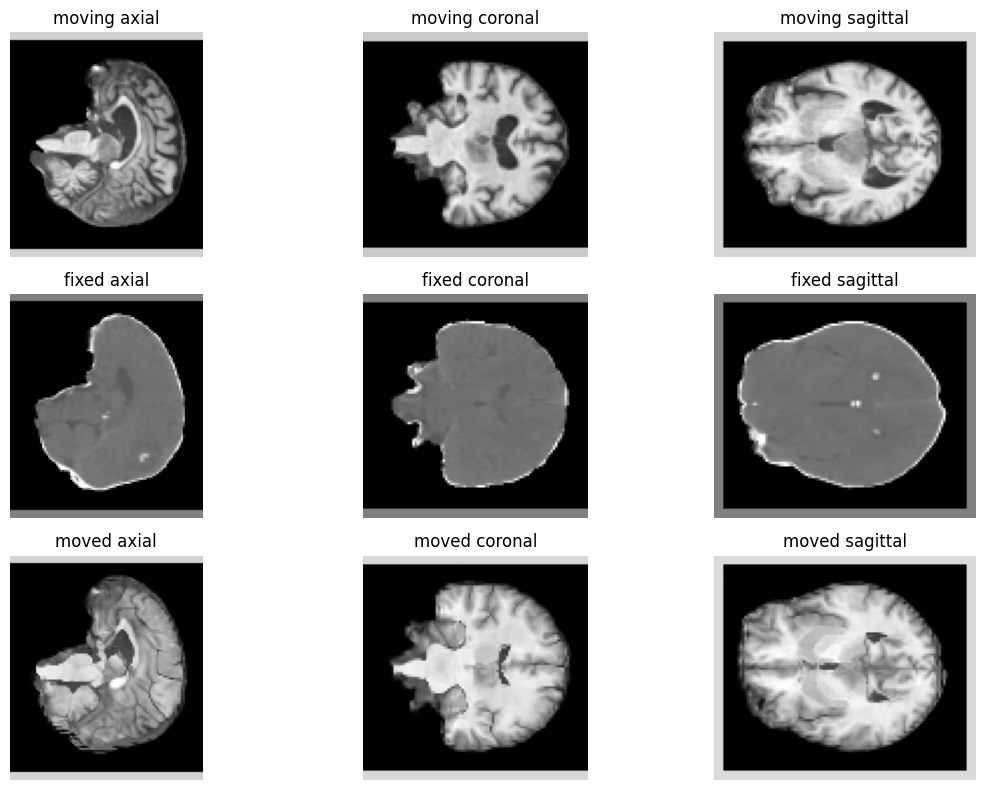

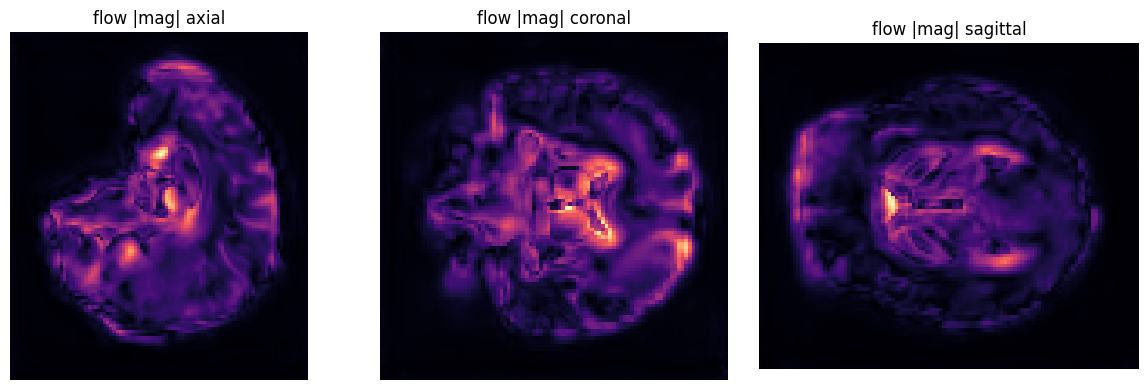

In [10]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()


def mid_slices(vol):
    return [
        vol[vol.shape[0] // 2],
        vol[:, vol.shape[1] // 2, :],
        vol[:, :, vol.shape[2] // 2],
    ]


def visualise_pair(pair_idx=0):
    moving_idx, fixed_idx = val_pair_indices[pair_idx]
    batch = build_cross_subject_batch(val_ds, moving_idx, fixed_idx, device=device)
    with torch.no_grad():
        moved, flow = model(batch['moving'], batch['fixed'])

    trio = [
        ('moving', batch['moving'][0, 0].cpu().numpy()),
        ('fixed', batch['fixed'][0, 0].cpu().numpy()),
        ('moved', moved[0, 0].cpu().numpy()),
    ]
    views = ['axial', 'coronal', 'sagittal']

    fig, axes = plt.subplots(3, 3, figsize=(12, 8))
    for row, (title, vol) in enumerate(trio):
        for col, slc in enumerate(mid_slices(vol)):
            axes[row, col].imshow(slc, cmap='gray')
            axes[row, col].set_title(f'{title} {views[col]}')
            axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

    flow_mag = np.sqrt((flow[0].cpu().numpy() ** 2).sum(axis=0))
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, slc, name in zip(axes, mid_slices(flow_mag), views):
        ax.imshow(slc, cmap='magma')
        ax.set_title(f'flow |mag| {name}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


visualise_pair(0)


In [11]:
from scipy.ndimage import distance_transform_edt


def compute_dice_per_label(warped_seg, fixed_seg, labels=SEG_LABELS):
    dice_scores = []
    for lbl in labels:
        w = (warped_seg == lbl).astype(np.float32)
        f = (fixed_seg == lbl).astype(np.float32)
        inter = float((w * f).sum())
        union = float(w.sum() + f.sum())
        dice_scores.append(1.0 if union == 0.0 else 2.0 * inter / union)
    return np.array(dice_scores, dtype=np.float32)


def mutual_information_np(a, b, bins=64, clip_range=(-1.0, 1.0)):
    hist_2d, _, _ = np.histogram2d(a.ravel(), b.ravel(), bins=bins, range=[clip_range, clip_range])
    pxy = hist_2d / np.maximum(hist_2d.sum(), 1.0)
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)
    nz = pxy > 0
    return float((pxy[nz] * np.log(pxy[nz] / (px @ py)[nz])).sum())


def hausdorff_distance_95(seg1, seg2):
    if seg1.sum() == 0 and seg2.sum() == 0:
        return 0.0
    if seg1.sum() == 0 or seg2.sum() == 0:
        return float('inf')
    dt2 = distance_transform_edt(~seg2.astype(bool))
    d12 = dt2[seg1.astype(bool)]
    dt1 = distance_transform_edt(~seg1.astype(bool))
    d21 = dt1[seg2.astype(bool)]
    return float(max(np.percentile(d12, 95), np.percentile(d21, 95)))


def negative_jacobian_ratio(flow_np):
    d, h, w, _ = flow_np.shape
    grid = np.mgrid[:d, :h, :w].astype(np.float32).transpose(1, 2, 3, 0)
    deform = flow_np + grid
    jac = np.zeros((d, h, w, 3, 3), dtype=np.float32)
    for i in range(3):
        jac[..., i, 0] = np.gradient(deform[..., i], axis=0)
        jac[..., i, 1] = np.gradient(deform[..., i], axis=1)
        jac[..., i, 2] = np.gradient(deform[..., i], axis=2)
    det = (
        jac[..., 0, 0] * (jac[..., 1, 1] * jac[..., 2, 2] - jac[..., 1, 2] * jac[..., 2, 1])
        - jac[..., 0, 1] * (jac[..., 1, 0] * jac[..., 2, 2] - jac[..., 1, 2] * jac[..., 2, 0])
        + jac[..., 0, 2] * (jac[..., 1, 0] * jac[..., 2, 1] - jac[..., 1, 1] * jac[..., 2, 0])
    )
    return float(np.mean(det <= 0))


def warp_labels(flow, moving_seg):
    warped = np.zeros(TARGET_VOL_SHAPE, dtype=np.int16)
    for lbl in SEG_LABELS:
        mask = (moving_seg[:, 0].long() == lbl).float().unsqueeze(1)
        warped_mask = nearest_transformer(mask, flow)[0, 0].detach().cpu().numpy()
        warped[warped_mask > 0.5] = lbl
    return warped


def save_preview(base_dir, moving, fixed, moved, flow_mag):
    views = ['axial', 'coronal', 'sagittal']
    fig, axes = plt.subplots(4, 3, figsize=(12, 10))
    rows = [('moving', moving), ('fixed', fixed), ('moved', moved), ('flow |mag|', flow_mag)]
    for row_idx, (label, vol) in enumerate(rows):
        for col_idx, slc in enumerate(mid_slices(vol)):
            cmap = 'magma' if row_idx == 3 else 'gray'
            axes[row_idx, col_idx].imshow(slc, cmap=cmap)
            axes[row_idx, col_idx].set_title(f'{label} {views[col_idx]}')
            axes[row_idx, col_idx].axis('off')
    plt.tight_layout()
    fig.savefig(os.path.join(base_dir, 'preview.png'), dpi=150, bbox_inches='tight')
    plt.close(fig)


model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

pair_summaries = []
with torch.no_grad():
    for pair_idx, (moving_idx, fixed_idx) in enumerate(val_pair_indices):
        pair_dir = os.path.join(EVAL_DIR, f'pair_{pair_idx:02d}_m{moving_idx:03d}_f{fixed_idx:03d}')
        os.makedirs(pair_dir, exist_ok=True)

        batch = build_cross_subject_batch(val_ds, moving_idx, fixed_idx, device=device)
        moving = batch['moving']
        fixed = batch['fixed']
        moving_seg = batch['moving_seg']
        fixed_seg = batch['fixed_seg']

        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        moved, flow = model(moving, fixed)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        infer_ms = (time.perf_counter() - t0) * 1000.0

        moving_np = moving[0, 0].cpu().numpy()
        fixed_np = fixed[0, 0].cpu().numpy()
        moved_np = moved[0, 0].cpu().numpy()
        moving_seg_np = moving_seg[0, 0].cpu().numpy().astype(np.int16)
        fixed_seg_np = fixed_seg[0, 0].cpu().numpy().astype(np.int16)
        flow_np = flow[0].permute(1, 2, 3, 0).cpu().numpy()
        flow_mag = np.sqrt((flow[0].cpu().numpy() ** 2).sum(axis=0))
        warped_seg = warp_labels(flow, moving_seg)

        dice_before = compute_dice_per_label(moving_seg_np, fixed_seg_np)
        dice_after = compute_dice_per_label(warped_seg, fixed_seg_np)
        hd95_per_label = [
            hausdorff_distance_95((warped_seg == lbl).astype(np.uint8), (fixed_seg_np == lbl).astype(np.uint8))
            for lbl in SEG_LABELS
        ]

        summary = {
            'pair_index': pair_idx,
            'moving_idx': moving_idx,
            'fixed_idx': fixed_idx,
            'inference_time_ms': float(infer_ms),
            'mi_before': mutual_information_np(moving_np, fixed_np),
            'mi_after': mutual_information_np(moved_np, fixed_np),
            'dice_before': float(dice_before.mean()),
            'dice_after': float(dice_after.mean()),
            'dice_before_per_label': {str(lbl): float(score) for lbl, score in zip(SEG_LABELS, dice_before)},
            'dice_after_per_label': {str(lbl): float(score) for lbl, score in zip(SEG_LABELS, dice_after)},
            'hd95_mean': float(np.mean(hd95_per_label)),
            'negative_jacobian_ratio': negative_jacobian_ratio(flow_np),
            'flow_min': float(flow_np.min()),
            'flow_max': float(flow_np.max()),
            'flow_mean': float(flow_np.mean()),
            'flow_std': float(flow_np.std()),
        }

        np.save(os.path.join(pair_dir, 'warped_volume.npy'), moved_np)
        np.save(os.path.join(pair_dir, 'flow.npy'), flow_np)
        np.save(os.path.join(pair_dir, 'warped_seg.npy'), warped_seg)
        with open(os.path.join(pair_dir, 'summary.json'), 'w') as f:
            json.dump(summary, f, indent=2)
        save_preview(pair_dir, moving_np, fixed_np, moved_np, flow_mag)

        print(
            f"pair {pair_idx}: dice {summary['dice_before']:.4f} -> {summary['dice_after']:.4f}, "
            f"mi {summary['mi_before']:.4f} -> {summary['mi_after']:.4f}, "
            f"jac {summary['negative_jacobian_ratio']:.6f}"
        )
        pair_summaries.append(summary)

aggregate = {
    'dice_after_mean': float(np.mean([row['dice_after'] for row in pair_summaries])),
    'mi_after_mean': float(np.mean([row['mi_after'] for row in pair_summaries])),
    'hd95_mean': float(np.mean([row['hd95_mean'] for row in pair_summaries])),
    'negative_jacobian_ratio_mean': float(np.mean([row['negative_jacobian_ratio'] for row in pair_summaries])),
    'inference_time_ms_mean': float(np.mean([row['inference_time_ms'] for row in pair_summaries])),
}

with open(os.path.join(EVAL_DIR, 'summary.json'), 'w') as f:
    json.dump(pair_summaries, f, indent=2)
with open(os.path.join(EVAL_DIR, 'aggregate.json'), 'w') as f:
    json.dump(aggregate, f, indent=2)

print('Saved evaluation outputs to', EVAL_DIR)
aggregate


pair 0: dice 0.5636 -> 0.7645, mi 0.8329 -> 0.8906, jac 0.006050
pair 1: dice 0.6619 -> 0.7818, mi 0.8854 -> 0.9485, jac 0.004121
Saved evaluation outputs to ./artifacts/results/train_3d_v2


{'dice_after_mean': 0.773176908493042,
 'mi_after_mean': 0.9195309872561999,
 'hd95_mean': 1.24361927974862,
 'negative_jacobian_ratio_mean': 0.005085778614831349,
 'inference_time_ms_mean': 125.79790349900577}

In [12]:
print('Best val loss model is at', BEST_MODEL_PATH)
print('Latest training state is at', LATEST_TRAIN_STATE_PATH)
